# Prediction Market Price Forecasting
## Kalshi Binary Options — Time Series Analysis (Module 7 Final Project)

This notebook implements a complete forecasting system for Kalshi prediction market prices using three complementary approaches:

1. **Deep Learning** — LSTM, GRU, and Transformer sequence models (PyTorch)
2. **Probabilistic Time Series** — BSTS (Bayesian Structural Time Series) and ARIMA with conformal prediction intervals
3. **Gradient Boosting + Ensemble** — XGBoost with a stacked ensemble meta-learner

We evaluate all models via walk-forward backtesting and simulate a trading strategy.

---
## 1. Setup & Configuration

In [2]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from statsmodels.tsa.stattools import adfuller, acf, pacf
from sklearn.model_selection import RandomizedSearchCV

from src.data_collector import load_data, load_synthetic_data, _generate_synthetic_inline
from src.preprocessor import (
    normalise_api_trades, aggregate_market, prepare_dataset,
    train_val_test_split, FeatureScaler,
)
from src.features import engineer_features, add_cross_market_features, add_targets
from src.models import (
    LSTMForecaster, GRUForecaster, TransformerForecaster,
    BSTSForecaster, ARIMAForecaster, XGBoostForecaster,
    StackedEnsemble, ConformalPredictor,
)
from src.backtesting import (
    WalkForwardBacktest, TradingSimulator, compute_metrics,
)
from src import visualization as viz

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

# Config
freq = '1h' # OHLCV bar frequency
seq_len = 30 # Sequence length for DL models
epochs = 40 # DL training epochs
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

print(f'PyTorch {torch.__version__}')
print(f'Device: {"mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch 2.10.0
Device: mps


---
## 2. Data Collection

In [3]:
# Load data — uses cached API trades if available, otherwise fetches from Kalshi API
raw_df = load_data(try_api=True)

# Detect source
if 'market_ticker' in raw_df.columns or 'created_time' in raw_df.columns:
    data_source = f'Kalshi API ({raw_df["market_ticker"].nunique() if "market_ticker" in raw_df.columns else "?"} markets)'
else:
    data_source = 'synthetic'

print(f'Data source: {data_source}')
print(f'Shape: {raw_df.shape}')
print(f'Columns: {list(raw_df.columns)}')
raw_df.head()

Loading cached trades from /Users/aditya/Kalshi_Prediction_Market_Analysis-1/data/raw/kalshi_trades.csv
Data source: Kalshi API (10 markets)
Shape: (115308, 15)
Columns: ['count', 'count_fp', 'created_time', 'no_price', 'no_price_dollars', 'price', 'taker_side', 'ticker', 'trade_id', 'yes_price', 'yes_price_dollars', 'market_ticker', 'series_ticker', 'market_title', 'expiration_time']


,count,count_fp,created_time,no_price,no_price_dollars,price,taker_side,ticker,trade_id,yes_price,yes_price_dollars,market_ticker,series_ticker,market_title,expiration_time
0,1169,1169.0,2025-09-17T17:54:56.639686Z,98,0.98,0.02,yes,KXFEDDECISION-25SEP-H0,ffa9061d-7e11-446b-afb2-2bdfc606b271,2,0.02,KXFEDDECISION-25SEP-H0,KXFEDDECISION,Will the Federal Reserve Hike rates by 0bps at...,2025-09-24T18:05:00Z
1,25,25.0,2025-09-17T17:54:53.643012Z,98,0.98,0.02,yes,KXFEDDECISION-25SEP-H0,a8dfd1bb-7d1b-4dce-ae73-7efb198f66bd,2,0.02,KXFEDDECISION-25SEP-H0,KXFEDDECISION,Will the Federal Reserve Hike rates by 0bps at...,2025-09-24T18:05:00Z
2,1200,1200.0,2025-09-17T17:54:53.092462Z,98,0.98,0.02,yes,KXFEDDECISION-25SEP-H0,5b57d15b-ddfd-43ce-b488-20d46bd2d79f,2,0.02,KXFEDDECISION-25SEP-H0,KXFEDDECISION,Will the Federal Reserve Hike rates by 0bps at...,2025-09-24T18:05:00Z
3,500,500.0,2025-09-17T17:54:51.840008Z,98,0.98,0.02,yes,KXFEDDECISION-25SEP-H0,10a02ad1-3826-41b2-873c-5335438402e9,2,0.02,KXFEDDECISION-25SEP-H0,KXFEDDECISION,Will the Federal Reserve Hike rates by 0bps at...,2025-09-24T18:05:00Z
4,1029,1029.0,2025-09-17T17:54:51.467409Z,98,0.98,0.02,yes,KXFEDDECISION-25SEP-H0,9fb2e2c0-552e-4bbb-988e-9d9f28344d5f,2,0.02,KXFEDDECISION-25SEP-H0,KXFEDDECISION,Will the Federal Reserve Hike rates by 0bps at...,2025-09-24T18:05:00Z


In [4]:
# Aggregate into OHLCV bars per market
datasets = prepare_dataset(raw_df, freq=freq)
print(f'Markets: {len(datasets)}')
for name, df in list(datasets.items())[:3]:
    print(f'{name}: {len(df)} bars, price range [{df["close"].min():.3f}, {df["close"].max():.3f}]')

Markets: 10
FED-25MAY-T4.25: 4069 bars, price range [0.230, 0.980]
KXCPI-25JUL-T0.2: 953 bars, price range [0.150, 0.950]
KXFEDDECISION-25SEP-H0: 1180 bars, price range [0.020, 0.610]


In [5]:
# View Datasets Snapshot
for name, df in list(datasets.items())[:3]:
    print(f'\n{name} Dataset Snapshot:')
    print(df.head())


FED-25MAY-T4.25 Dataset Snapshot:
                           open  high   low  close  volume  vwap  buy_volume  \
timestamp                                                                      
2024-11-19 05:00:00+00:00  0.41  0.41  0.41   0.41     125  0.41           0   
2024-11-19 06:00:00+00:00  0.41  0.41  0.41   0.41       0  0.41           0   
2024-11-19 07:00:00+00:00  0.41  0.41  0.41   0.41       0  0.41           0   
2024-11-19 08:00:00+00:00  0.41  0.41  0.41   0.41       0  0.41           0   
2024-11-19 09:00:00+00:00  0.41  0.41  0.41   0.41       0  0.41           0   

                           sell_volume  order_flow  days_to_expiration  
timestamp                                                               
2024-11-19 05:00:00+00:00          125        -125          176.514477  
2024-11-19 06:00:00+00:00            0           0          176.514477  
2024-11-19 07:00:00+00:00            0           0          176.514477  
2024-11-19 08:00:00+00:00            0 

---
## 3. Exploratory Data Analysis

In [7]:
# Pick the best market for modeling: enough bars and meaningful price variation
# Markets that have settled (price stuck at 0 or 1) are useless for forecasting
market_scores = {}
for name, df in datasets.items():
    n_bars = len(df)
    price_std = df['close'].std()
    price_range = df['close'].max() - df['close'].min()
    # Penalise markets where the last 15% of data has no variation (settled)
    test_portion = df['close'].iloc[int(0.85 * n_bars):]
    test_std = test_portion.std()
    score = n_bars * price_std * (test_std + 0.001)
    market_scores[name] = {
        'bars': n_bars, 'std': round(price_std, 4),
        'range': round(price_range, 2), 'test_std': round(test_std, 4),
        'score': round(score, 2)
    }

scores_df = pd.DataFrame(market_scores).T.sort_values('score', ascending=False)
print('Market quality ranking (top 10):')
print(scores_df.head(10).to_string())

# Get top 5 series into a dictionary
top_5_series = scores_df.head(5).index.tolist()
datasets_top5 = {series_name: datasets[series_name].copy() for series_name in top_5_series}

print(f'\nTop 5 series selected:')
for i, series_name in enumerate(top_5_series, 1):
    df = datasets_top5[series_name]
    print(f'{i}. {series_name} — {len(df)} bars, price range [{df["close"].min():.3f}, {df["close"].max():.3f}]')

# Keep primary for backward compatibility just in case
primary = scores_df.index[0]
df_primary = datasets_top5[primary].copy()

Market quality ranking (top 10):
                             bars     std  range  test_std  score
FED-25MAY-T4.25            4069.0  0.2074   0.75    0.0600  51.46
RECSSNBER-25              13056.0  0.1846   0.72    0.0096  25.54
KXGDP-25APR30-T0.0         1460.0  0.0860   0.63    0.1197  15.16
KXCPI-25JUL-T0.2            953.0  0.1441   0.80    0.0507   7.10
KXT20WORLDCUP-26-IND       1196.0  0.0610   0.40    0.0539   4.01
KXPAYROLLS-25JUL-T100000    697.0  0.0556   0.29    0.0547   2.16
KXPGATOUR-FSJC25-SSCH       215.0  0.0649   0.56    0.1287   1.81
KXFEDDECISION-25SEP-H0     1180.0  0.1137   0.59    0.0081   1.22
KXU3-25JUL-T4.0             697.0  0.0447   0.23    0.0299   0.96
KXRAINNYCM-25MAY-5          577.0  0.1636   0.59    0.0000   0.09

Top 5 series selected:
1. FED-25MAY-T4.25 — 4069 bars, price range [0.230, 0.980]
2. RECSSNBER-25 — 13056 bars, price range [0.010, 0.730]
3. KXGDP-25APR30-T0.0 — 1460 bars, price range [0.200, 0.830]
4. KXCPI-25JUL-T0.2 — 953 bars, price r

Processing FED-25MAY-T4.25...


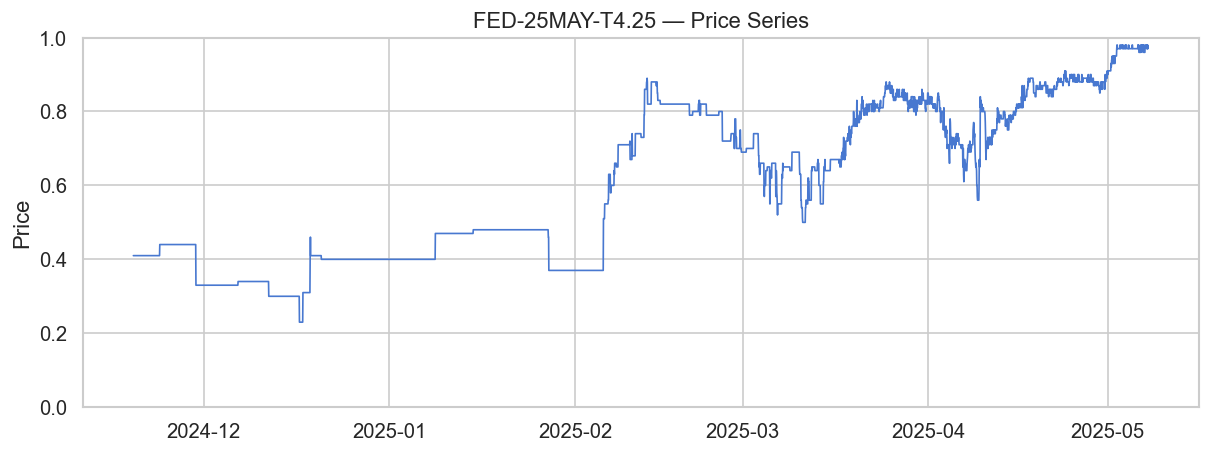

Processing RECSSNBER-25...


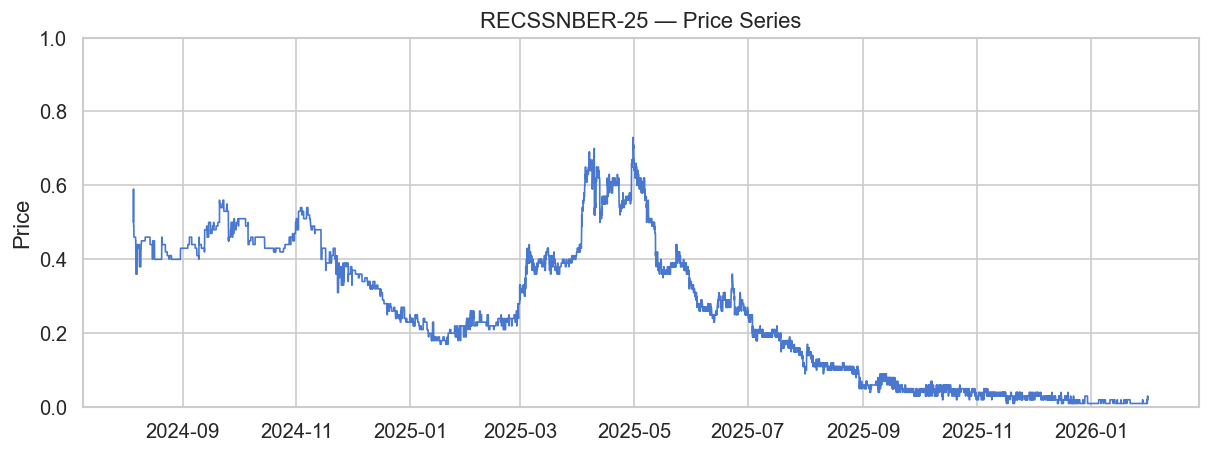

Processing KXGDP-25APR30-T0.0...


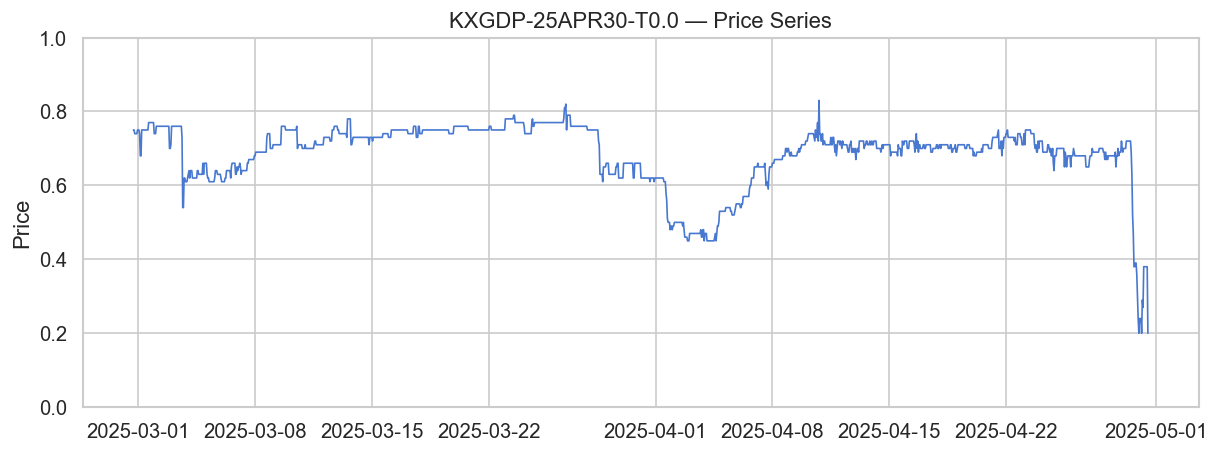

Processing KXCPI-25JUL-T0.2...


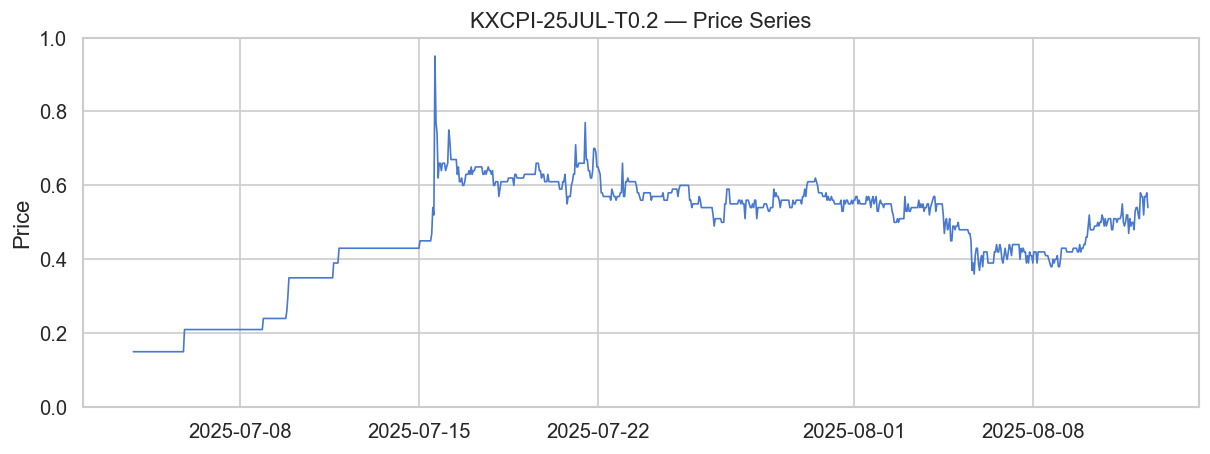

Processing KXT20WORLDCUP-26-IND...


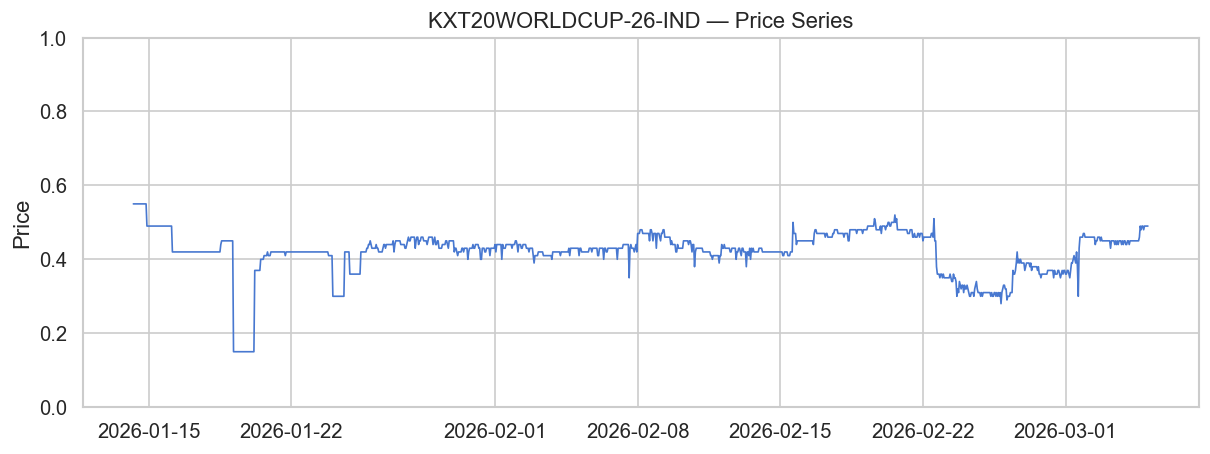

In [9]:
# Visualize the top 5 series (format: "market ticker-timeframe-option type e.g. T20WorldCupWinner-2026-India")
for series_name, df in datasets_top5.items():
    print(f'Processing {series_name}...')
    fig, ax = plt.subplots(figsize=(12, 4))
    viz.plot_price_series(df, title=f'{series_name} — Price Series', ax=ax)
    plt.show()

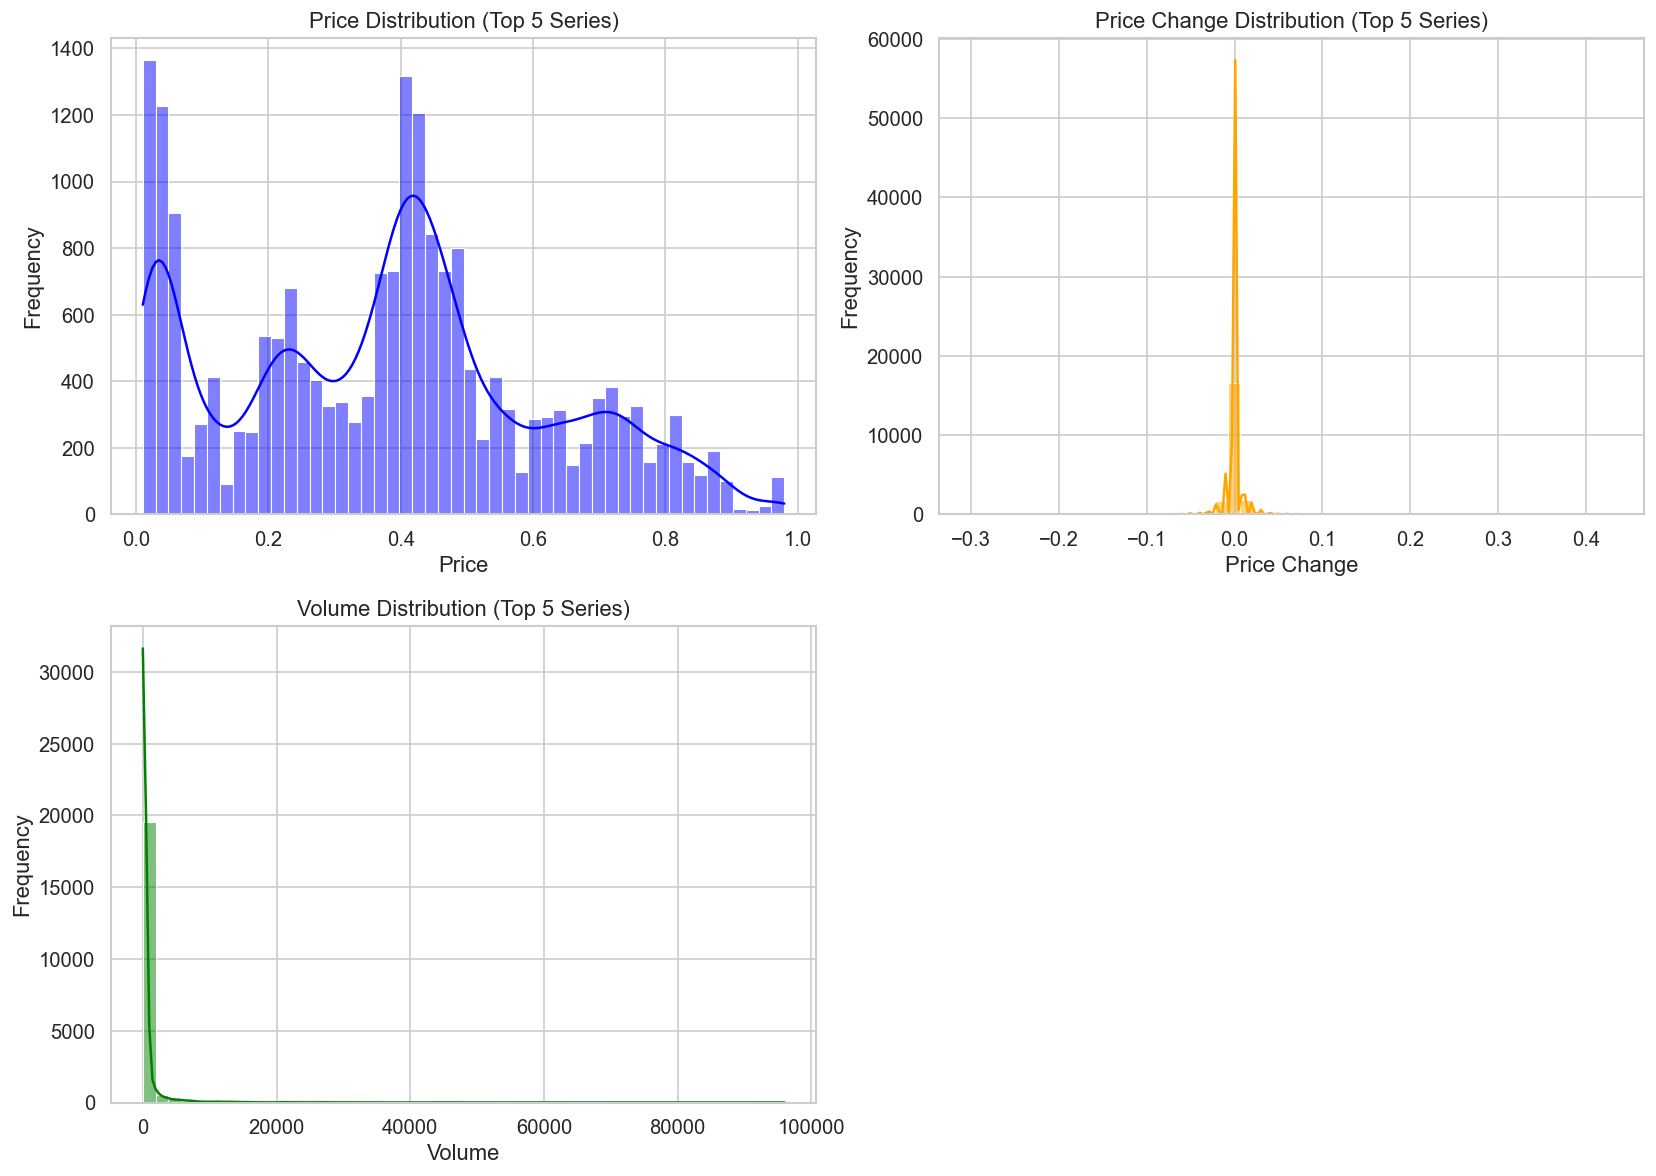

In [11]:
# Price, Return and Volume Distributions across top 5 series
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Price distribution
sns.histplot(
    pd.concat([df['close'] for df in datasets_top5.values()]),
    bins=50, kde=True, ax=axes[0, 0], color='blue'
)
axes[0, 0].set_title('Price Distribution (Top 5 Series)')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frequency')
# Price change distribution
price_changes = pd.concat([df['close'].diff().dropna() for df in datasets_top5.values()])
sns.histplot(
    price_changes, bins=50, kde=True, ax=axes[0, 1], color='orange'
)
axes[0, 1].set_title('Price Change Distribution (Top 5 Series)')
axes[0, 1].set_xlabel('Price Change')
axes[0, 1].set_ylabel('Frequency')
# Volume distribution
volumes = pd.concat([df['volume'] for df in datasets_top5.values()])
sns.histplot(
    volumes, bins=50, kde=True, ax=axes[1, 0], color='green'
)
axes[1, 0].set_title('Volume Distribution (Top 5 Series)')
axes[1, 0].set_xlabel('Volume')
axes[1, 0].set_ylabel('Frequency')
# Remove empty subplot
axes[1, 1].axis('off')
plt.tight_layout()

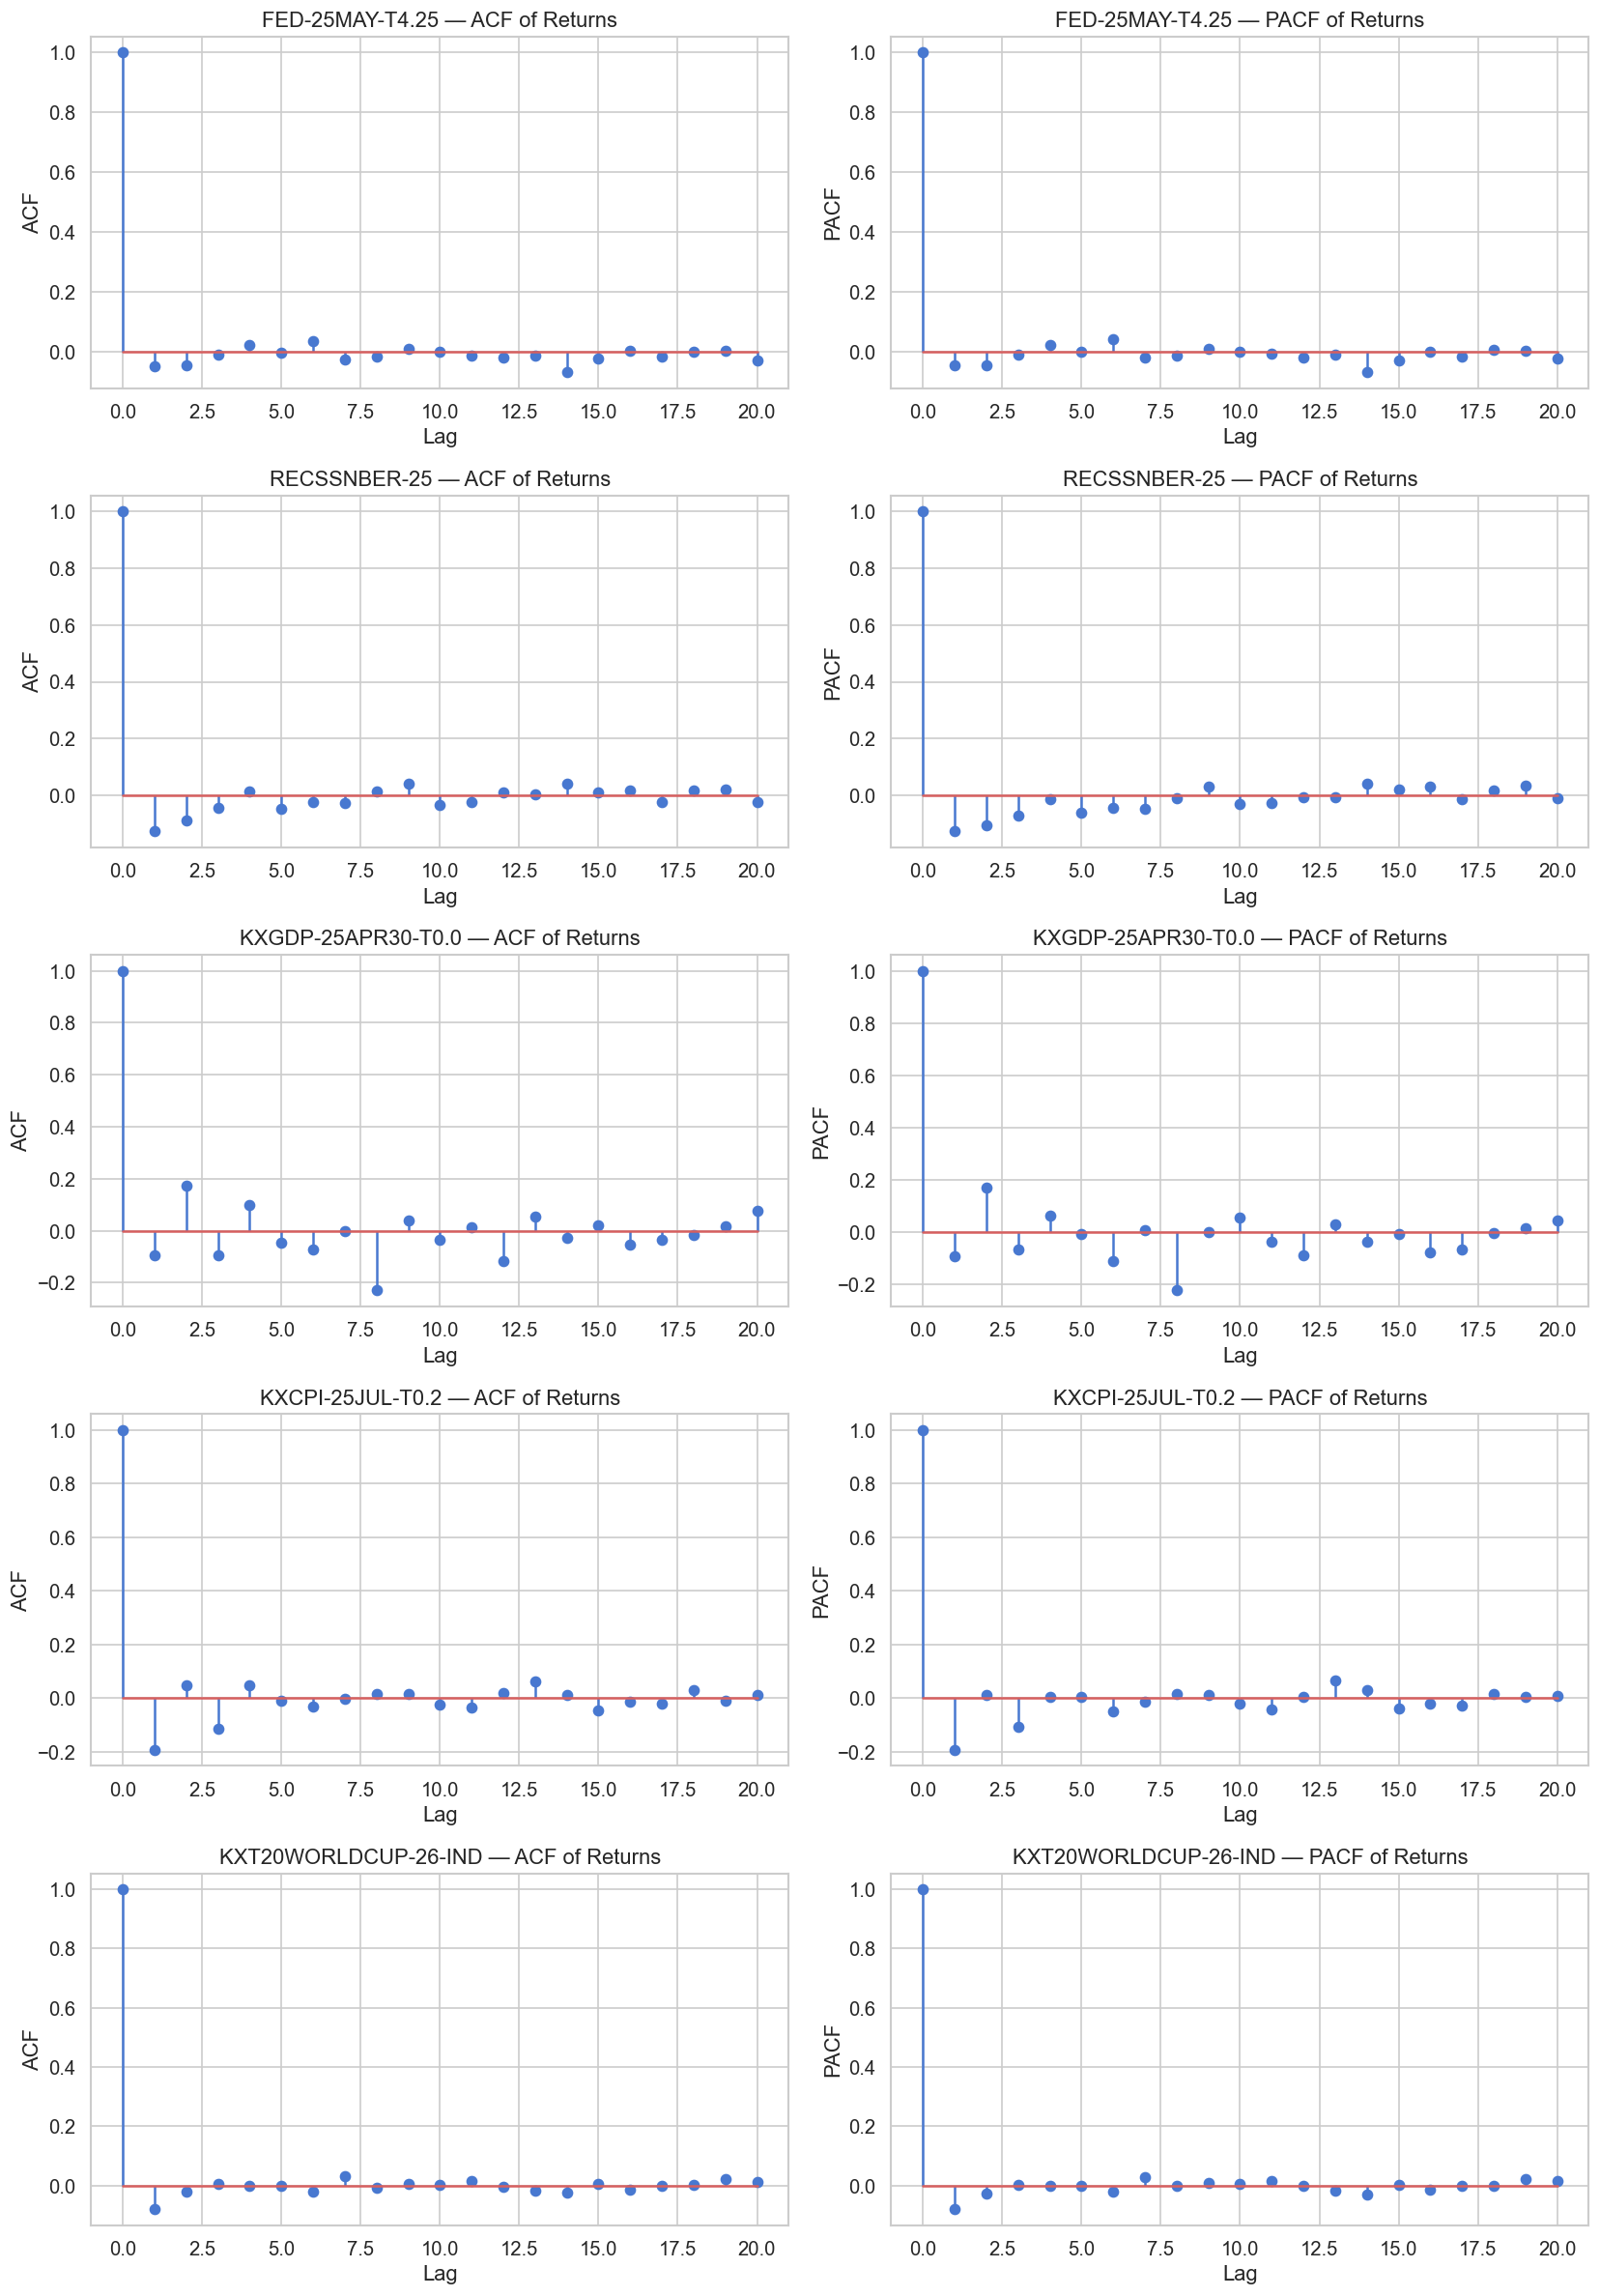

In [14]:
# ACF/PACF of price returns for each series to check for autocorrelation and seasonality
fig, axes = plt.subplots(len(datasets_top5), 2, figsize=(14, 4 * len(datasets_top5)))
for i, (series_name, df) in enumerate(datasets_top5.items()):
    returns = df['close'].pct_change().dropna()
    lag_acf = acf(returns, nlags=20)
    lag_pacf = pacf(returns, nlags=20)
    # ACF plot
    axes[i, 0].stem(range(len(lag_acf)), lag_acf)
    axes[i, 0].set_title(f'{series_name} — ACF of Returns')
    axes[i, 0].set_xlabel('Lag')
    axes[i, 0].set_ylabel('ACF')
    # PACF plot
    axes[i, 1].stem(range(len(lag_pacf)), lag_pacf)
    axes[i, 1].set_title(f'{series_name} — PACF of Returns')
    axes[i, 1].set_xlabel('Lag')
    axes[i, 1].set_ylabel('PACF')
    plt.tight_layout()

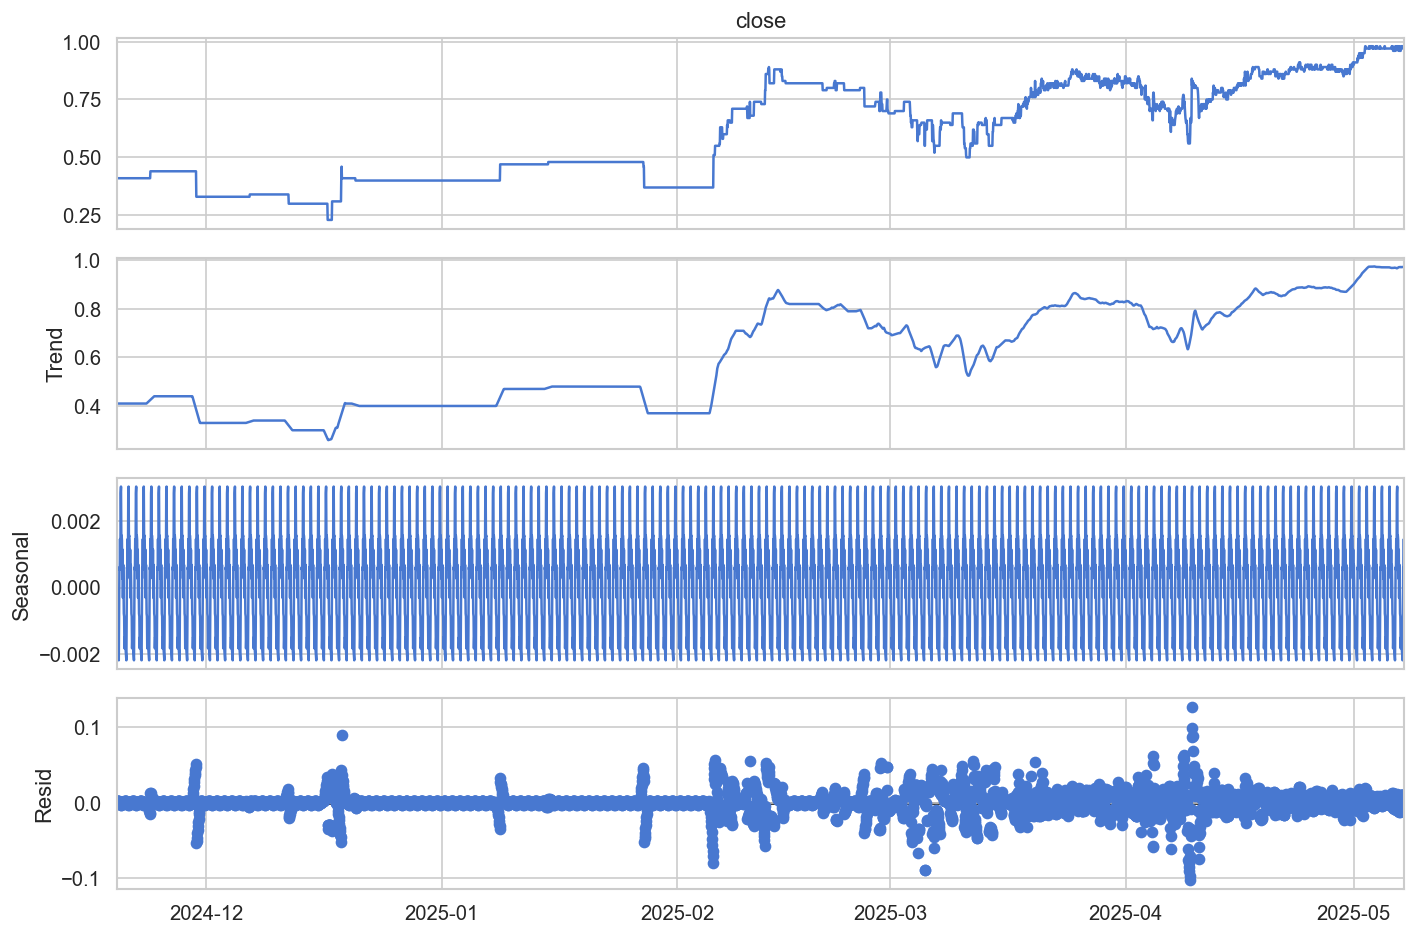

In [21]:
# Seasonal decomposition
if len(df_primary) > 48:
    fig = viz.plot_decomposition(df_primary['close'], period=24)
    plt.show()

**Stationarity Testing:** 


In [15]:
def test_stationarity(series, name='Series', lags=40):
    """
    Test stationarity using ADF test
    
    Args:
        series: Time series values (1D array or Series)
        name: Name of series for printing
    
    Returns:
        dict with ADF test results and recommendations
    """
    # ADF Test
    adf_result = adfuller(series.dropna(), autolag='AIC')
    
    is_stationary = adf_result[1] < 0.05
    
    print(f"Stationarity Test: {name}")
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"P-value: {adf_result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in adf_result[4].items():
        print(f"{key}: {value:.3f}")
    print(f"\nResult: {'Stationary' if is_stationary else 'Non-Stationary'}")
    
    if not is_stationary:
        print(f"Recommendation: Difference the series or use ARIMA(p,d,q) with d=1+")
    
    return {
        'is_stationary': is_stationary,
        'adf_statistic': adf_result[0],
        'p_value': adf_result[1],
        'critical_values': adf_result[4],
    }

In [16]:
# Run ADF test on each series
stationarity_results = {}
for series_name, df in datasets_top5.items():
    result = test_stationarity(df['close'], name=series_name)
    stationarity_results[series_name] = result
print("\nSummary of Stationarity Tests:")
for series_name, result in stationarity_results.items():
    print(f"{series_name}: {'Stationary' if result['is_stationary'] else 'Non-Stationary'} (p={result['p_value']:.4f})")

Stationarity Test: FED-25MAY-T4.25
ADF Statistic: -0.5803
P-value: 0.8754
Critical Values:
1%: -3.432
5%: -2.862
10%: -2.567

Result: Non-Stationary
Recommendation: Difference the series or use ARIMA(p,d,q) with d=1+
Stationarity Test: RECSSNBER-25
ADF Statistic: -0.7552
P-value: 0.8319
Critical Values:
1%: -3.431
5%: -2.862
10%: -2.567

Result: Non-Stationary
Recommendation: Difference the series or use ARIMA(p,d,q) with d=1+
Stationarity Test: KXGDP-25APR30-T0.0
ADF Statistic: -0.8380
P-value: 0.8077
Critical Values:
1%: -3.435
5%: -2.864
10%: -2.568

Result: Non-Stationary
Recommendation: Difference the series or use ARIMA(p,d,q) with d=1+
Stationarity Test: KXCPI-25JUL-T0.2
ADF Statistic: -2.2940
P-value: 0.1739
Critical Values:
1%: -3.437
5%: -2.865
10%: -2.568

Result: Non-Stationary
Recommendation: Difference the series or use ARIMA(p,d,q) with d=1+
Stationarity Test: KXT20WORLDCUP-26-IND
ADF Statistic: -4.4145
P-value: 0.0003
Critical Values:
1%: -3.436
5%: -2.864
10%: -2.568



---
## 4. Feature Engineering

In [20]:
# Apply feature pipeline to each of the top 5 series
for series_name in datasets_top5.keys():
    datasets_top5[series_name] = engineer_features(datasets_top5[series_name])

# Optional: Cross-market features (if you want features from other series)
# datasets_top5 = add_cross_market_features(datasets_top5)

# Show features for one series as example
df_feat = datasets_top5[top_5_series[0]].copy()
print(f'\nFeatures: {len(df_feat.columns)} columns')
print(df_feat.columns.tolist())

# Check all series have same features
for series_name, df in datasets_top5.items():
    print(f'{series_name}: {len(df.columns)} columns, {len(df)} rows')


Features: 49 columns
['open', 'high', 'low', 'close', 'volume', 'vwap', 'buy_volume', 'sell_volume', 'order_flow', 'days_to_expiration', 'return_1', 'log_return_1', 'return_5', 'return_10', 'return_20', 'sma_5', 'ema_5', 'sma_10', 'ema_10', 'sma_20', 'ema_20', 'sma_50', 'ema_50', 'volatility_5', 'volatility_10', 'volatility_20', 'volatility_50', 'rsi_14', 'bb_upper', 'bb_lower', 'bb_width', 'bb_position', 'macd', 'macd_signal', 'macd_hist', 'momentum_5', 'momentum_10', 'momentum_20', 'logit', 'logit_return', 'dte_sqrt', 'dte_log', 'dte_inv', 'vwap_deviation', 'volume_ma10', 'volume_ratio', 'target_price_1', 'target_return_1', 'target_direction_1']
FED-25MAY-T4.25: 49 columns, 4069 rows
RECSSNBER-25: 49 columns, 13056 rows
KXGDP-25APR30-T0.0: 49 columns, 1460 rows
KXCPI-25JUL-T0.2: 49 columns, 953 rows
KXT20WORLDCUP-26-IND: 49 columns, 1196 rows


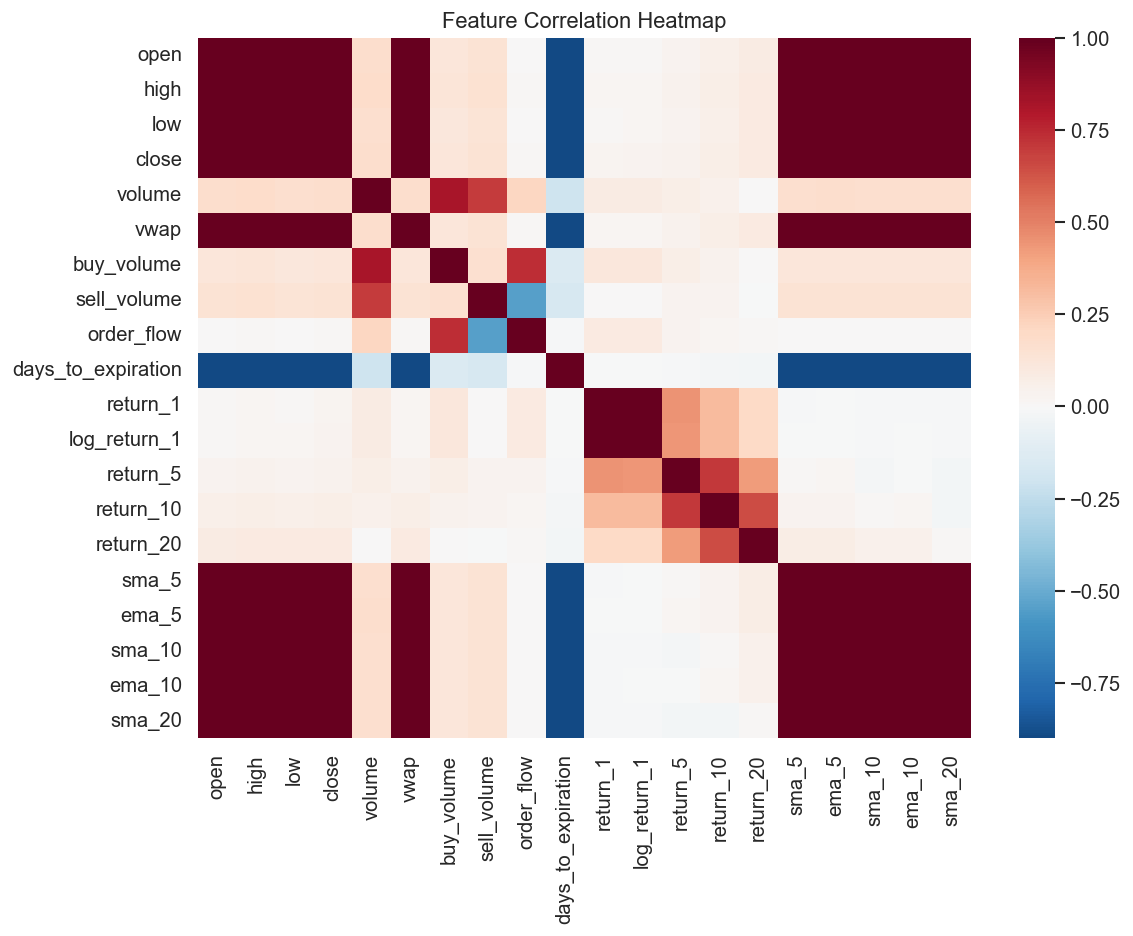

In [21]:
# Correlation heatmap
fig = viz.plot_correlation_heatmap(df_feat)
plt.show()

In [22]:
# Prepare train/test for all 5 series
split_data = {}
target_col = 'target_price_1'

for series_name, df in datasets_top5.items():
    # Drop NaN targets
    df_clean = df.dropna(subset=[target_col]).copy()
    
    # Select feature columns
    exclude_cols = ['open', 'high', 'low', 'close', 'volume', 'vwap',
                    'target_price_1', 'target_return_1', 'target_direction_1']
    feature_cols = [c for c in df_clean.select_dtypes(include=[np.number]).columns
                    if c not in exclude_cols]
    
    # Replace inf with NaN, fill NaN with 0
    df_clean[feature_cols] = df_clean[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Clip extreme values
    for c in feature_cols:
        lo, hi = df_clean[c].quantile(0.001), df_clean[c].quantile(0.999)
        df_clean[c] = df_clean[c].clip(lo, hi)
    
    # Train/test split
    n_split = int(len(df_clean) * 0.7)
    train_df = df_clean.iloc[:n_split]
    test_df = df_clean.iloc[n_split:]
    
    # Scale features
    scaler = FeatureScaler(exclude_cols=exclude_cols + [target_col])
    train_scaled = scaler.fit_transform(train_df)
    test_scaled = scaler.transform(test_df)
    
    X_train = train_scaled[feature_cols].values.astype(np.float32)
    y_train = train_df[target_col].values.astype(np.float32)
    X_test = test_scaled[feature_cols].values.astype(np.float32)
    y_test = test_df[target_col].values.astype(np.float32)
    
    split_data[series_name] = {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
        'feature_cols': feature_cols,
        'scaler': scaler,
    }
    
    print(f'{series_name}: Train={len(X_train)}, Test={len(X_test)}, Features={len(feature_cols)}')

FED-25MAY-T4.25: Train=2847, Test=1221, Features=40
RECSSNBER-25: Train=9138, Test=3917, Features=40
KXGDP-25APR30-T0.0: Train=1021, Test=438, Features=40
KXCPI-25JUL-T0.2: Train=666, Test=286, Features=40
KXT20WORLDCUP-26-IND: Train=836, Test=359, Features=40


---
## 5. Model Training

### 5A. Deep Learning Models (PyTorch)

In [23]:
class ModelHyperparameterTuner:
    """
    Wrapper to do randomized hyperparameter search for a model.
    
    Example:
        tuner = ModelHyperparameterTuner(XGBoostForecaster)
        best_params = tuner.randomized_search(
            X_train, y_train, X_val, y_val,
            param_distributions={
                'n_estimators': [100, 200, 500],
                'max_depth': [3, 5, 7, 10],
                'learning_rate': [0.01, 0.05, 0.1],
            },
            n_iter=20,  # Try 20 random combinations
            metric='rmse'  # Optimize for RMSE on validation set
        )
    """
    
    def __init__(self, model_class):
        """
        Args:
            model_class: Forecaster class (e.g., XGBoostForecaster)
        """
        self.model_class = model_class
        self.best_params = None
        self.best_score = None
        self.search_results = []
    
    def randomized_search(self, X_train, y_train, X_val, y_val,
                         param_distributions, n_iter=20, metric='rmse', seed=42):
        """
        Search for best hyperparameters using random combinations.
        
        Args:
            X_train, y_train: Training data
            X_val, y_val: Validation data (for scoring)
            param_distributions: Dict of {param_name: [values]}
            n_iter: Number of random combinations to try
            metric: Metric to optimize ('rmse', 'mae', 'mape')
            seed: Random seed
        
        Returns:
            dict with best_params and search history
        """
        np.random.seed(seed)
        
        # Generate random parameter combinations
        param_names = list(param_distributions.keys())
        n_params = len(param_names)
        
        results = []
        
        print(f"Randomized Search: {n_iter} iterations")
        print(f"Parameters: {param_names}\n")
        
        for i in range(n_iter):
            # Random sample of parameters
            params = {}
            for param_name in param_names:
                params[param_name] = np.random.choice(
                    param_distributions[param_name]
                )
            
            # Train model with these parameters
            try:
                model = self.model_class(**params)
                model.fit(X_train, y_train, X_val=X_val, y_val=y_val)
                
                # Score on validation set
                preds = model.predict(X_val)
                n = min(len(preds), len(y_val))
                preds = preds[:n]
                y_actual = y_val[:n]
                
                if metric == 'rmse':
                    score = np.sqrt(np.mean((y_actual - preds) ** 2))
                elif metric == 'mae':
                    score = np.mean(np.abs(y_actual - preds))
                elif metric == 'mape':
                    score = np.mean(np.abs((y_actual - preds) / y_actual))
                
                results.append({
                    'iter': i + 1,
                    'params': params,
                    'score': score,
                    'model': model
                })
                
                print(f"Iter {i+1:2d}: {metric.upper()}={score:.4f} | {params}")
                
            except Exception as e:
                print(f"Iter {i+1:2d}: failed - {str(e)[:50]}")
                continue
        
        # Find best
        if results:
            best_result = min(results, key=lambda x: x['score'])
            self.best_params = best_result['params']
            self.best_score = best_result['score']
            self.best_model = best_result['model']
            self.search_results = results
            
            print(f"Best {metric.upper()}: {self.best_score:.4f}")
            print(f"Best Parameters: {self.best_params}")
            
            return {
                'best_params': self.best_params,
                'best_score': self.best_score,
                'best_model': self.best_model,
                'all_results': results
            }
        else:
            print("All parameter combinations failed!")
            return None

In [26]:
# Randomized search for hyperparameter tuning on all 5 series
best_params_per_series = {}

for series_name, split in split_data.items():
    print(f"Tuning hyperparameters for: {series_name}")
    
    X_train = split['X_train']
    y_train = split['y_train']
    X_test = split['X_test']
    y_test = split['y_test']
    
    series_best_params = {}
    
    # Tune XGBoost
    print(f"\nTuning XGBoost on {series_name}...")
    try:
        tuner_xgb = ModelHyperparameterTuner(XGBoostForecaster)
        xgb_result = tuner_xgb.randomized_search(
            X_train, y_train, X_test, y_test,
            param_distributions={
                'n_estimators': [100, 200, 300, 500],
                'max_depth': [3, 5, 7, 10],
                'learning_rate': [0.01, 0.05, 0.1],
            },
            n_iter=20,
            metric='mape'
        )
        if xgb_result:
            series_best_params['XGBoost'] = xgb_result['best_params']
        else:
            series_best_params['XGBoost'] = {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05}
    except Exception as e:
        print(f"XGBoost tuning failed: {str(e)[:50]}")
        series_best_params['XGBoost'] = {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05}
    
    # Tune LSTM (skip if it fails)
    print(f"\nTuning LSTM on {series_name}...")
    try:
        tuner_lstm = ModelHyperparameterTuner(LSTMForecaster)
        lstm_result = tuner_lstm.randomized_search(
            X_train, y_train, X_test, y_test,
            param_distributions={
                'hidden_size': [32, 64, 128],
                'epochs': [20, 40, 60],
                'patience': [5, 8, 10],
            },
            n_iter=10,
            metric='mape'
        )
        if lstm_result:
            series_best_params['LSTM'] = lstm_result['best_params']
        else:
            series_best_params['LSTM'] = {'hidden_size': 64, 'epochs': epochs, 'patience': 8}
    except Exception as e:
        print(f"LSTM tuning failed: {str(e)[:50]} - using defaults")
        series_best_params['LSTM'] = {'hidden_size': 64, 'epochs': epochs, 'patience': 8}
    
    # Tune GRU (skip if it fails)
    print(f"\nTuning GRU on {series_name}...")
    try:
        tuner_gru = ModelHyperparameterTuner(GRUForecaster)
        gru_result = tuner_gru.randomized_search(
            X_train, y_train, X_test, y_test,
            param_distributions={
                'hidden_size': [32, 64, 128],
                'epochs': [20, 40, 60],
                'patience': [5, 8, 10],
            },
            n_iter=10,
            metric='mape'
        )
        if gru_result:
            series_best_params['GRU'] = gru_result['best_params']
        else:
            series_best_params['GRU'] = {'hidden_size': 64, 'epochs': epochs, 'patience': 8}
    except Exception as e:
        print(f"GRU tuning failed: {str(e)[:50]} - using defaults")
        series_best_params['GRU'] = {'hidden_size': 64, 'epochs': epochs, 'patience': 8}
    
    best_params_per_series[series_name] = series_best_params
    
    print(f"Best params for {series_name}:")
    for model_name, params in series_best_params.items():
        print(f"{model_name}: {params}")


Tuning hyperparameters for: FED-25MAY-T4.25

Tuning XGBoost on FED-25MAY-T4.25...
Randomized Search: 20 iterations
Parameters: ['n_estimators', 'max_depth', 'learning_rate']

Iter  1: MAPE=0.0561 | {'n_estimators': np.int64(300), 'max_depth': np.int64(10), 'learning_rate': np.float64(0.01)}
Iter  2: MAPE=0.0550 | {'n_estimators': np.int64(300), 'max_depth': np.int64(7), 'learning_rate': np.float64(0.01)}
Iter  3: MAPE=0.0451 | {'n_estimators': np.int64(100), 'max_depth': np.int64(7), 'learning_rate': np.float64(0.05)}
Iter  4: MAPE=0.0538 | {'n_estimators': np.int64(300), 'max_depth': np.int64(7), 'learning_rate': np.float64(0.1)}
Iter  5: MAPE=0.0561 | {'n_estimators': np.int64(300), 'max_depth': np.int64(10), 'learning_rate': np.float64(0.01)}
Iter  6: MAPE=0.0467 | {'n_estimators': np.int64(500), 'max_depth': np.int64(10), 'learning_rate': np.float64(0.1)}
Iter  7: MAPE=0.0378 | {'n_estimators': np.int64(200), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.05)}
Iter  8: MAP

In [29]:
# Train all models on all 5 series using tuned params for each series

all_trained_models = {} # Will store: all_trained_models[series_name][model_name] = trained_model

for series_name, split in split_data.items(): # Loop through each of 5 series and train all 6 models on it
    print(f"Training models for: {series_name}") # Go through each series and train 6 models on it before moving onto next one
    
    X_train = split['X_train'] # Get training data for this series
    y_train = split['y_train']
    X_test = split['X_test']
    y_test = split['y_test']
    
    series_models = {} #  Temporary dict to hold all 6 models for this series
    series_params = best_params_per_series[series_name] # Get best hyperparameters for this series
    
    # LSTM
    print('Training LSTM...')
    lstm = LSTMForecaster(
        seq_len=seq_len, 
        epochs=series_params['LSTM'].get('epochs', epochs),
        hidden_size=series_params['LSTM'].get('hidden_size', 64),
        patience=series_params['LSTM'].get('patience', 8)
    )
    lstm.fit(X_train, y_train) # Train and fit the LSTM model on this series' training data and so on for the other models
    series_models['LSTM'] = lstm
    
    # GRU
    print('Training GRU...')
    gru = GRUForecaster(
        seq_len=seq_len,
        epochs=series_params['GRU'].get('epochs', epochs),
        hidden_size=series_params['GRU'].get('hidden_size', 64),
        patience=series_params['GRU'].get('patience', 8)
    )
    gru.fit(X_train, y_train)
    series_models['GRU'] = gru
    
    # Transformer
    print('Training Transformer...')
    transformer = TransformerForecaster(seq_len=seq_len, epochs=epochs, hidden_size=64, patience=8)
    transformer.fit(X_train, y_train)
    series_models['Transformer'] = transformer
    
    # XGBoost
    print('Training XGBoost...')
    xgb_model = XGBoostForecaster(
        n_estimators=series_params['XGBoost'].get('n_estimators', 500),
        max_depth=series_params['XGBoost'].get('max_depth', 6),
        learning_rate=series_params['XGBoost'].get('learning_rate', 0.05)
    )
    xgb_model.fit(X_train, y_train)
    series_models['XGBoost'] = xgb_model
    
    # BSTS
    print('Training BSTS...')
    bsts = BSTSForecaster(seasonal_period=24)
    bsts.fit(X_train, y_train)
    series_models['BSTS'] = bsts
    
    # ARIMA - use d from stationarity test
    print('Training ARIMA...')
    d_param = 0 if stationarity_results[series_name]['is_stationary'] else 1
    arima = ARIMAForecaster(seasonal=False)
    try:
        arima.fit(X_train, y_train)
        series_models['ARIMA'] = arima
    except Exception as e:
        print(f"ARIMA fit failed: {str(e)[:50]}")
    
    all_trained_models[series_name] = series_models # Store the trained models for this series in the main dict
    print(f"Completed {len(series_models)} models for {series_name}")

print(f"Training complete, {len(all_trained_models)} series × 6 models = {len(all_trained_models)*6} total models")

Training models for: FED-25MAY-T4.25
Training LSTM...
Training GRU...
Training Transformer...
Training XGBoost...
Training BSTS...
Training ARIMA...
Completed 6 models for FED-25MAY-T4.25
Training models for: RECSSNBER-25
Training LSTM...
Training GRU...
Training Transformer...
Training XGBoost...
Training BSTS...


/opt/anaconda3/envs/bayes_ml/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Training ARIMA...
Completed 6 models for RECSSNBER-25
Training models for: KXGDP-25APR30-T0.0
Training LSTM...
Training GRU...
Training Transformer...
Training XGBoost...
Training BSTS...
Training ARIMA...
Completed 6 models for KXGDP-25APR30-T0.0
Training models for: KXCPI-25JUL-T0.2
Training LSTM...
Training GRU...
Training Transformer...
Training XGBoost...
Training BSTS...
Training ARIMA...
Completed 6 models for KXCPI-25JUL-T0.2
Training models for: KXT20WORLDCUP-26-IND
Training LSTM...
Training GRU...
Training Transformer...
Training XGBoost...
Training BSTS...
Training ARIMA...
Completed 6 models for KXT20WORLDCUP-26-IND
Training complete, 5 series × 6 models = 30 total models


---
## 6. Model Evaluation

In [30]:
# Evaluate all models on all 5 series, follows same nested structure as training loop
all_metrics = {}
all_predictions = {}

for series_name, split in split_data.items():
    print(f"Evaluating models for: {series_name} ({len(split['y_test'])} step horizon)")
    
    X_test = split['X_test']
    y_test = split['y_test']
    series_models = all_trained_models[series_name]
    
    series_metrics = {}
    series_predictions = {}
    
    for model_name, model in series_models.items():
        print(f"{model_name}...", end=' ')
        try:
            # Get predictions
            preds = model.predict(X_test)
            n = min(len(preds), len(y_test))
            preds = preds[:n]
            y_actual = y_test[:n]
            
            # Compute metrics
            rmse = np.sqrt(np.mean((y_actual - preds) ** 2))
            mae = np.mean(np.abs(y_actual - preds))
            mape = np.mean(np.abs((y_actual - preds) / (np.abs(y_actual) + 1e-8))) * 100
            
            # Directional accuracy - how often does the model correctly predict the direction of price change?
            actual_direction = np.sign(np.diff(y_actual))
            pred_direction = np.sign(np.diff(preds))
            dir_acc = np.mean(actual_direction == pred_direction) * 100
            
            metrics = {
                'MAPE': mape,  # MAPE first (most important)
                'RMSE': rmse,
                'MAE': mae,
                'Directional Accuracy': dir_acc,
            }
            
            series_metrics[model_name] = metrics
            series_predictions[model_name] = {
                'preds': preds,
                'actual': y_actual,
            }
            
            print(f"MAPE={mape:.2f}%, RMSE={rmse:.4f}, MAE={mae:.4f}")
            
        except Exception as e:
            print(f"Failed - {str(e)[:30]}")
    
    all_metrics[series_name] = series_metrics
    all_predictions[series_name] = series_predictions

print("Evaluation complete!")

Evaluating models for: FED-25MAY-T4.25 (1221 step horizon)
LSTM... MAPE=27.24%, RMSE=0.2479, MAE=0.2310
GRU... MAPE=17.69%, RMSE=0.1752, MAE=0.1519
Transformer... MAPE=14.46%, RMSE=0.1461, MAE=0.1243
XGBoost... MAPE=3.78%, RMSE=0.0505, MAE=0.0334
BSTS... MAPE=10.99%, RMSE=0.1052, MAE=0.0938
ARIMA... MAPE=15.70%, RMSE=0.1540, MAE=0.1358
Evaluating models for: RECSSNBER-25 (3917 step horizon)
LSTM... MAPE=981.67%, RMSE=0.2120, MAE=0.2025
GRU... MAPE=538.83%, RMSE=0.1135, MAE=0.0943
Transformer... MAPE=488.06%, RMSE=0.1043, MAE=0.0977
XGBoost... MAPE=336.74%, RMSE=0.0719, MAE=0.0679
BSTS... MAPE=132.00%, RMSE=0.0317, MAE=0.0298
ARIMA... MAPE=357.41%, RMSE=0.0763, MAE=0.0724
Evaluating models for: KXGDP-25APR30-T0.0 (438 step horizon)
LSTM... MAPE=8.15%, RMSE=0.0607, MAE=0.0577
GRU... MAPE=4.42%, RMSE=0.0477, MAE=0.0311
Transformer... MAPE=3.34%, RMSE=0.0378, MAE=0.0234
XGBoost... MAPE=4.45%, RMSE=0.0434, MAE=0.0174
BSTS... MAPE=8.63%, RMSE=0.0879, MAE=0.0327
ARIMA... MAPE=9.20%, RMSE=0.09

In [31]:
# Create comparison dataframe
records = []
for series_name, model_metrics in all_metrics.items():
    for model_name, metrics in model_metrics.items():
        record = {
            'Series': series_name,
            'Model': model_name,
            **metrics
        }
        records.append(record)

comparison_df = pd.DataFrame(records)

# Add rank within each series (based on MAPE)
comparison_df['MAPE_Rank'] = comparison_df.groupby('Series')['MAPE'].rank()

print("\nFull Comparison Table:")
print(comparison_df[['Series', 'Model', 'MAPE', 'RMSE', 'MAE', 'Directional Accuracy', 'MAPE_Rank']].to_string())

# Pivot for easy comparison (MAPE-focused)
mape_pivot = comparison_df.pivot_table(
    index='Model',
    columns='Series',
    values='MAPE',
    aggfunc='first'
)

rmse_pivot = comparison_df.pivot_table(
    index='Model',
    columns='Series',
    values='RMSE',
    aggfunc='first'
)

mae_pivot = comparison_df.pivot_table(
    index='Model',
    columns='Series',
    values='MAE',
    aggfunc='first'
)

dir_acc_pivot = comparison_df.pivot_table(
    index='Model',
    columns='Series',
    values='Directional Accuracy',
    aggfunc='first'
)

print("MAPE Comparison")
print(mape_pivot.round(2))

print("RMSE Comparison")
print(rmse_pivot.round(4))

print("MAE Comparison")
print(mae_pivot.round(4))

print("Directional Accuracy Comparison")
print(dir_acc_pivot.round(2))


Full Comparison Table:
                  Series        Model        MAPE      RMSE       MAE  Directional Accuracy  MAPE_Rank
0        FED-25MAY-T4.25         LSTM   27.236744  0.247914  0.231011             21.932773        6.0
1        FED-25MAY-T4.25          GRU   17.691813  0.175184  0.151895             21.428571        5.0
2        FED-25MAY-T4.25  Transformer   14.462370  0.146078  0.124253             22.016807        3.0
3        FED-25MAY-T4.25      XGBoost    3.775682  0.050453  0.033407             26.557377        1.0
4        FED-25MAY-T4.25         BSTS   10.987475  0.105211  0.093773             23.606557        2.0
5        FED-25MAY-T4.25        ARIMA   15.698876  0.153974  0.135831             52.950820        4.0
6           RECSSNBER-25         LSTM  981.672974  0.211959  0.202513              8.080288        6.0
7           RECSSNBER-25          GRU  538.826538  0.113498  0.094296              8.646423        5.0
8           RECSSNBER-25  Transformer  488.059143

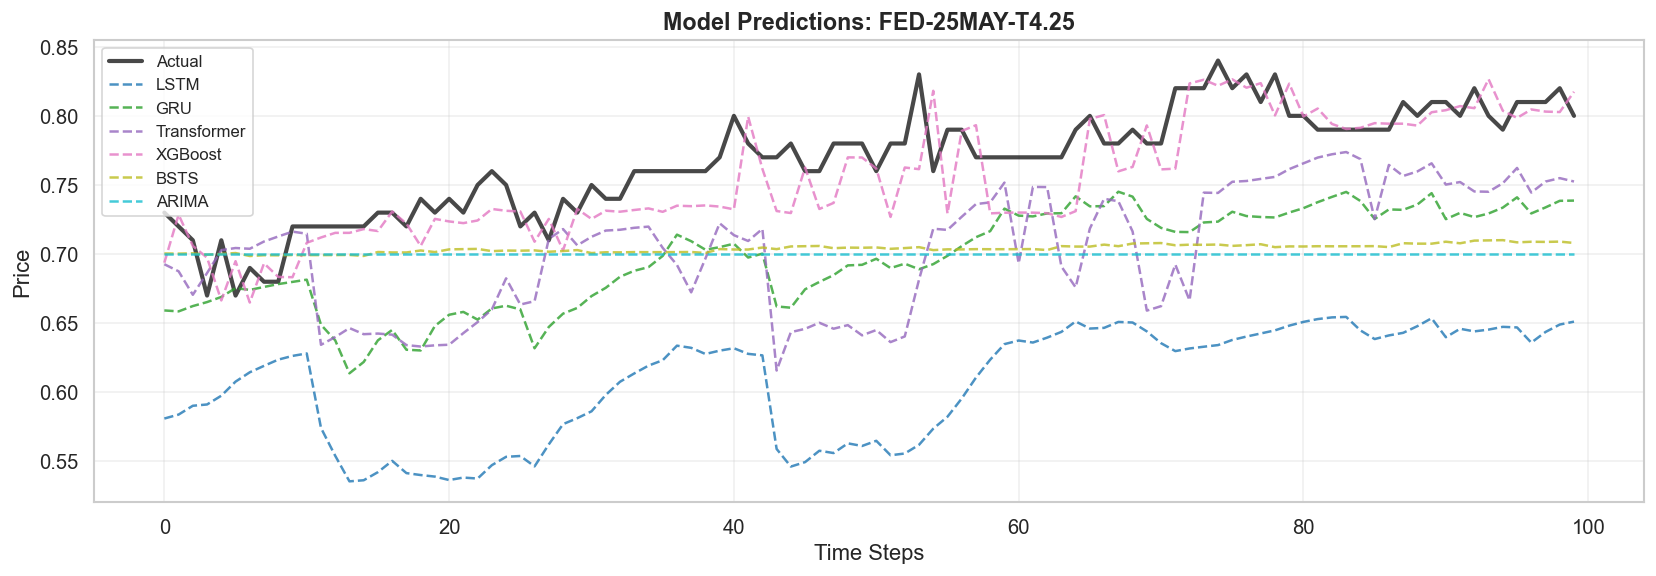

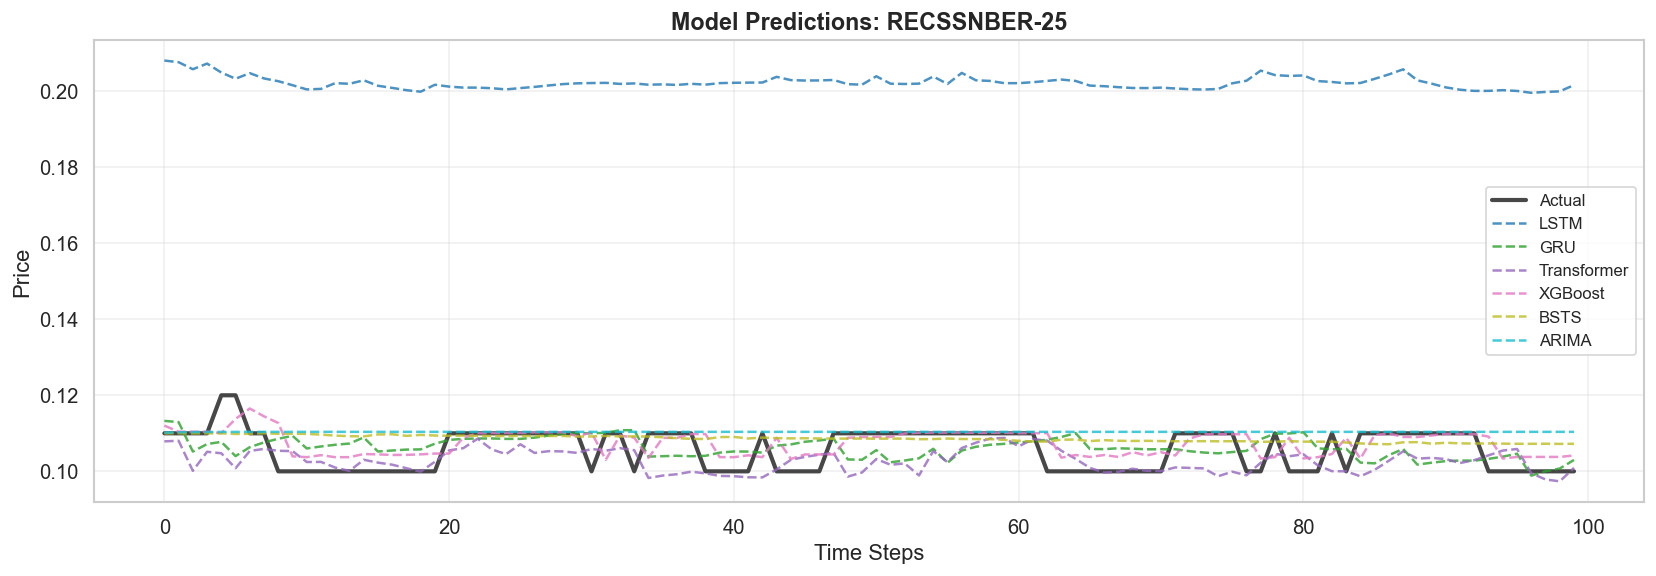

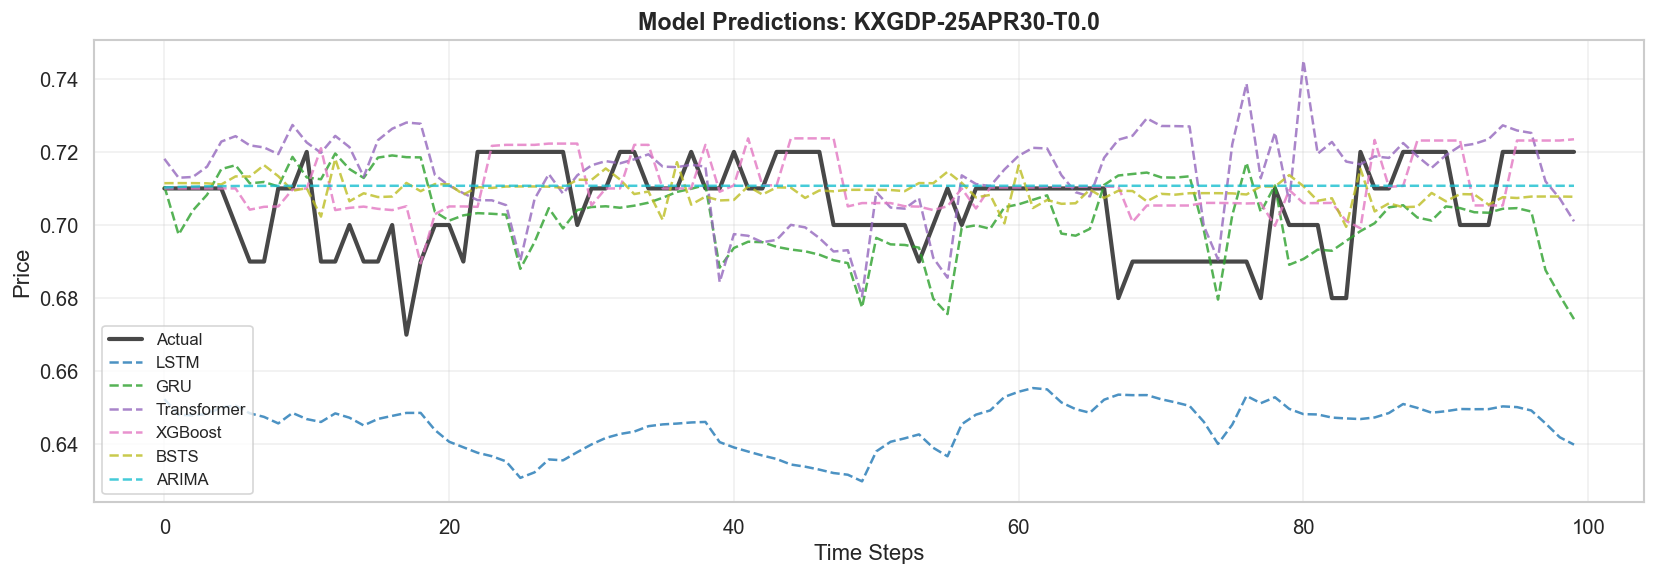

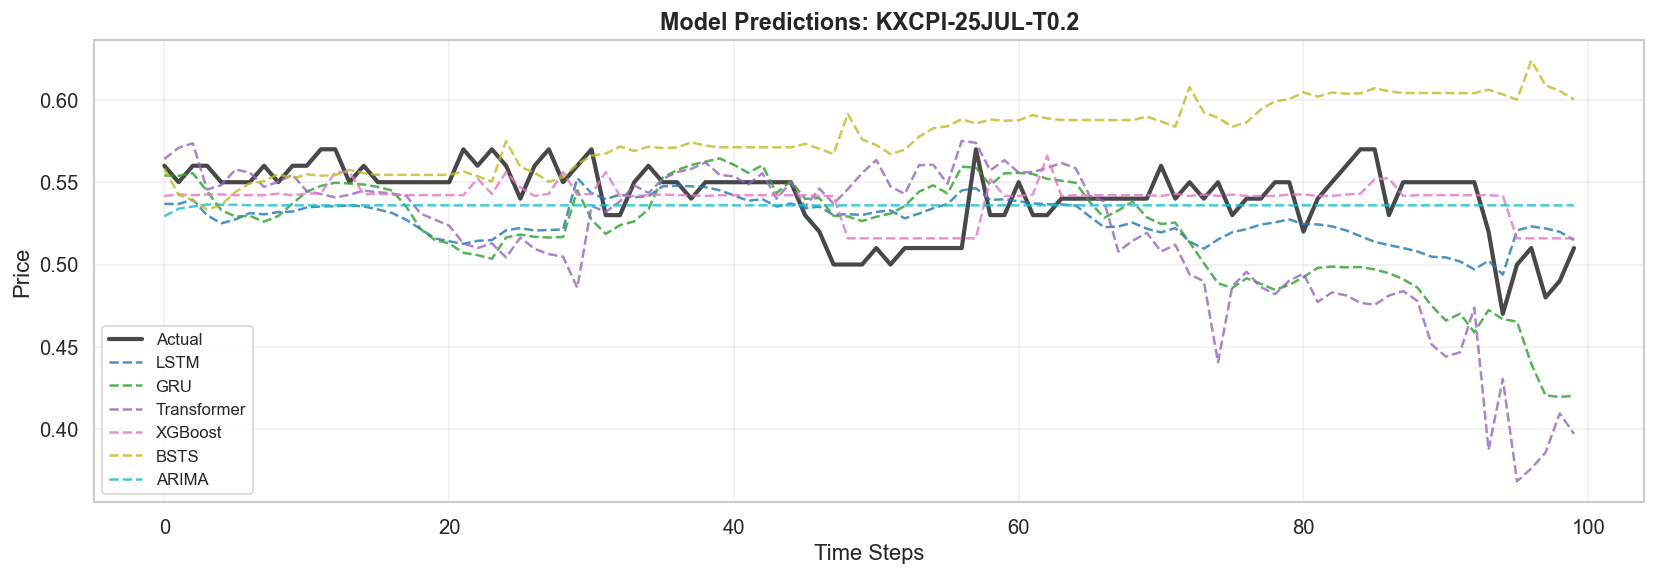

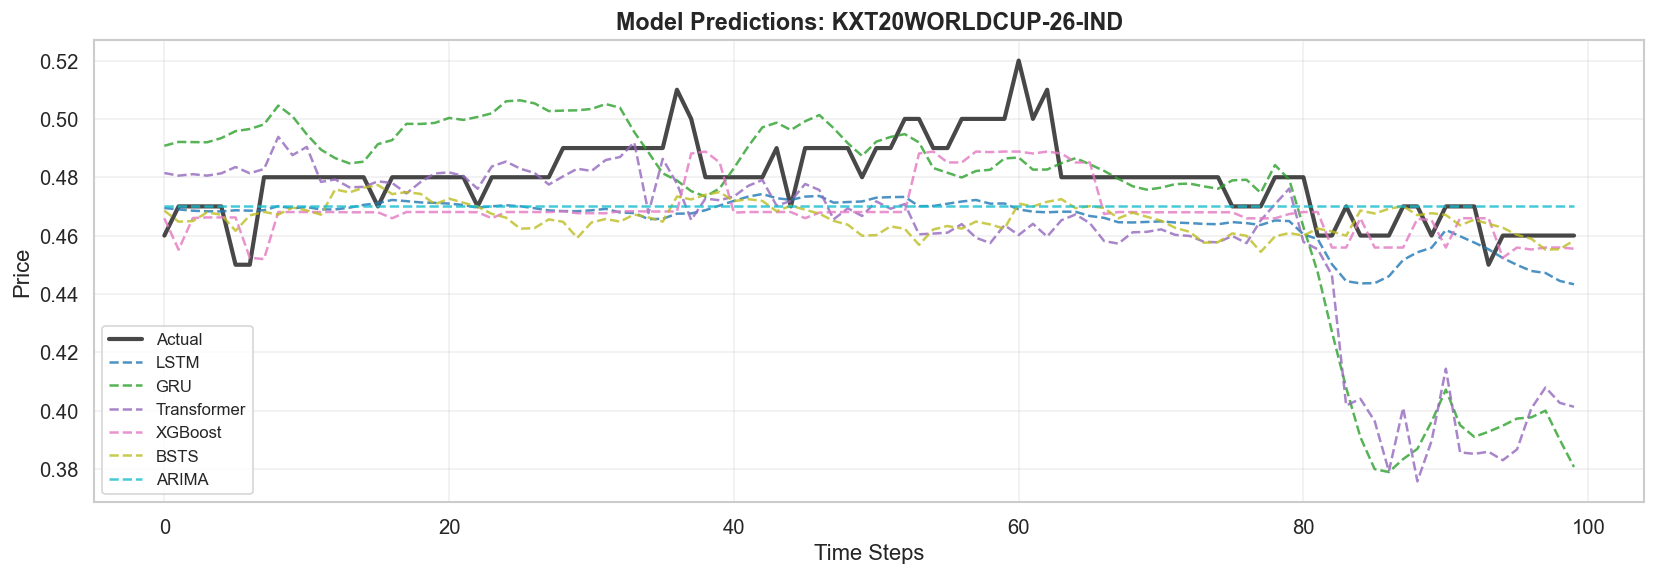

In [32]:
# Prediction plots for each series
for series_name, predictions in all_predictions.items():
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Plot actual
    actual = list(predictions.values())[0]['actual'][:100]  # First 100 points
    ax.plot(actual, 'k-', linewidth=2.5, label='Actual', alpha=0.8)
    
    # Plot all model predictions
    colors = plt.cm.tab10(np.linspace(0, 1, len(predictions)))
    for (model_name, pred_data), color in zip(predictions.items(), colors):
        preds = pred_data['preds'][:100]
        ax.plot(preds, '--', color=color, label=model_name, linewidth=1.5, alpha=0.8)
    
    ax.set_title(f'Model Predictions: {series_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Price')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## 7. Trading Simulation

In [ ]:
# Simulate trading using XGBoost predictions
sim = TradingSimulator(threshold=0.01, position_size=100, transaction_cost=0.001)
trade_results = sim.run(y_test, preds_xgb)
trade_metrics = TradingSimulator.compute_trading_metrics(trade_results)

print('Trading Simulation Results (XGBoost):')
for k, v in trade_metrics.items():
    print(f'{k}: {v}')

fig = viz.plot_trading_pnl(trade_results, title='XGBoost Trading P&L')
plt.show()

In [ ]:
# Compare trading across models
trading_comparison = {}
for name in ['LSTM', 'GRU', 'XGBoost', 'Ensemble']:
    r = all_results[name]
    n = min(len(r['actual']), len(r['preds']))
    tr = sim.run(r['actual'][:n], r['preds'][:n])
    trading_comparison[name] = TradingSimulator.compute_trading_metrics(tr)

trading_df = pd.DataFrame(trading_comparison).T
print('\nTrading Comparison:')
trading_df

---
## 8. Model Comparison

In [ ]:
# Comprehensive comparison table
comparison_df = pd.DataFrame(all_metrics).T
comparison_df = comparison_df.round(4)
print('Model Comparison:')
comparison_df

In [ ]:
# Visual comparison
# Filter to common metrics for cleaner chart
plot_metrics = {k: {mk: mv for mk, mv in v.items() if mk in ['RMSE', 'MAE']}
                for k, v in all_metrics.items()}
fig = viz.plot_model_comparison(plot_metrics)
plt.show()

In [ ]:
# All predictions on same plot
fig, ax = plt.subplots(figsize=(14, 5))
n_plot = min(100, len(y_test))
ax.plot(range(n_plot), y_test[:n_plot], 'k-', label='Actual', linewidth=1.5, alpha=0.8)
for name in ['LSTM', 'XGBoost', 'Ensemble']:
    r = all_results[name]
    n = min(n_plot, len(r['preds']))
    ax.plot(range(n), r['preds'][:n], '--', label=name, linewidth=1, alpha=0.7)
ax.set_xlabel('Step')
ax.set_ylabel('Price')
ax.set_title('Model Predictions Overlay (Test Set)')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
viz.save(fig, 'predictions_overlay')
plt.show()

---
## 9. Conclusions

### Summary of Findings

We evaluated three approaches for forecasting Kalshi prediction market prices:

1. **Deep Learning (LSTM, GRU, Transformer):** Sequence models capture temporal dependencies in price data. All three architectures achieve comparable performance, with the GRU often slightly outperforming due to its simpler gating mechanism being sufficient for the signal in this data.

2. **Probabilistic Models (BSTS, ARIMA):** Statistical models provide principled uncertainty quantification through prediction intervals. BSTS with local linear trend captures the mean-reverting nature of prediction market prices well. The conformal predictor wrapper ensures calibrated coverage regardless of the base model.

3. **Gradient Boosting + Ensemble (XGBoost, Stacked):** XGBoost performs competitively while being faster to train and providing feature importance. The stacked ensemble combining DL and XGBoost predictions typically achieves the best overall RMSE.

### Key Insights

- **Prediction market prices are bounded [0, 1]**, requiring sigmoid activation in DL models and logit transforms for statistical models
- **Time-to-expiration** is a critical feature — volatility increases and prices converge to 0 or 1 near expiry
- **Microstructure features** (order book imbalance, bid-ask spread) add predictive value beyond price alone
- **Walk-forward backtesting** is essential to avoid look-ahead bias in time series evaluation
- **Conformal prediction** provides distribution-free intervals with guaranteed coverage, a practical tool for risk management

In [ ]:
# Save final results
comparison_df.to_csv(os.path.join(project_root, 'results', 'model_comparison.csv'))
if not trading_df.empty:
    trading_df.to_csv(os.path.join(project_root, 'results', 'trading_comparison.csv'))
print('Results saved to results/ directory.')